In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
import tensorflow_hub as hub
import numpy as np
import os
import random
import time
from glob import glob
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import tensorflow_datasets as tfds
import seaborn as sns
from PIL import Image
from tensorflow.keras.applications import vgg19
from keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import torch
import cv2
import shutil as sh
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display
%matplotlib inline

# **Task1**

In [ ]:
#load dataset
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_test = y_test.reshape(-1,)

In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [ ]:
#normalize the training data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Build CNN model
cnn = models.Sequential([
    #  Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


In [ ]:
# Compile Model
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # use this if labels are integers
    metrics=['accuracy']
)

In [ ]:
#model summary
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:
#training
history = cnn.fit(X_train, y_train, epochs=100,batch_size=64,validation_data=(X_test, y_test),callbacks=[early_stop])


Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.3626 - loss: 2.0305 - val_accuracy: 0.5451 - val_loss: 1.3332
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6147 - loss: 1.0861 - val_accuracy: 0.6241 - val_loss: 1.1007
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6849 - loss: 0.8904 - val_accuracy: 0.7179 - val_loss: 0.8121
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7210 - loss: 0.7898 - val_accuracy: 0.7432 - val_loss: 0.7330
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7530 - loss: 0.7110 - val_accuracy: 0.7357 - val_loss: 0.7691
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7754 - loss: 0.6477 - val_accuracy: 0.7922 - val_loss: 0.6000
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7891 - loss: 0.6033 - val_accuracy: 0.7953 - val_loss: 0.5983
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8056 - loss: 0.5562 - 

In [ ]:
#model evaluation
test_loss, test_acc = cnn.evaluate(X_test,y_test,verbose=2)
print(test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8481 - loss: 0.4608
0.8481000065803528


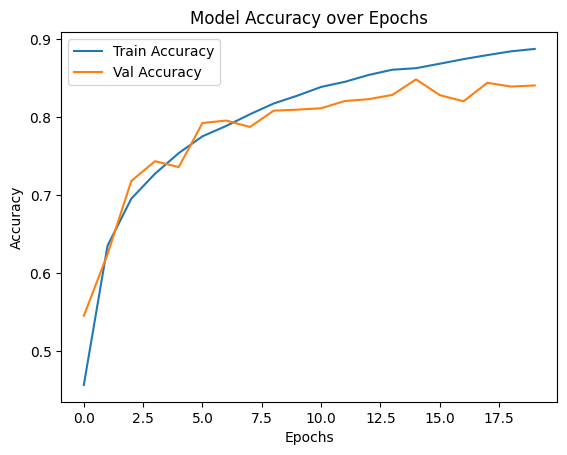

In [ ]:
#plot the tainnig data
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()


In [ ]:
pred= cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


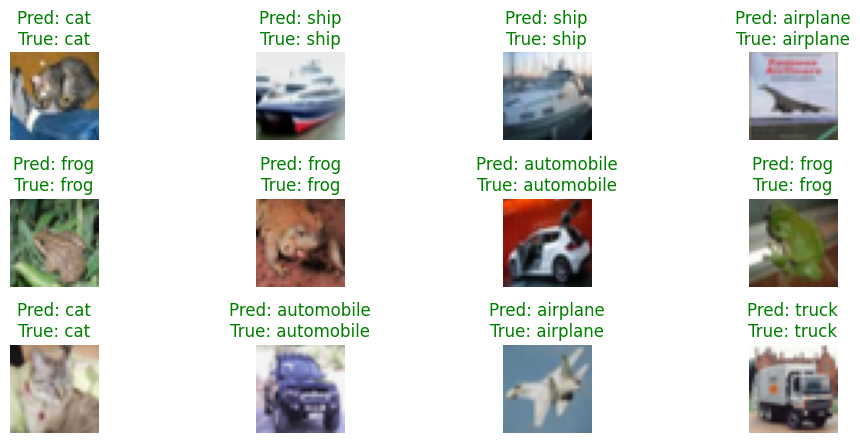

In [ ]:
#visualization
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[i])
    pred_label = classes[np.argmax(pred[i])]
    true_label = classes[y_test[i]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()



# **Task2**

In [ ]:
from zipfile import ZipFile
file_name = "/content/fer2013.zip"

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('done')

done


In [ ]:
#load dataset
TRAIN_DIR="/content/train/"
TEST_DIR="/content/test/"

In [ ]:
#trian and test into complete image path
def load_dataset(directory):
    image_paths=[]
    label=[]

    for label_dir in os.listdir(directory):
      for filename in os.listdir(directory+label_dir):
        image_path=directory+label_dir+"/"+filename
        image_paths.append(image_path) #for input
        label.append(label_dir) #for output

      print(label,"completed")

    return image_paths,label

In [ ]:
#Convert into Dataframe
train=pd.DataFrame()
train['image'],train['label']=load_dataset(TRAIN_DIR)
#shuffle the dataset
train=train.sample(frac=1).reset_index(drop=True)
train.head()

['neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral'

,image,label
0,/content/train/fear/Training_51455718.jpg,fear
1,/content/train/fear/Training_15309290.jpg,fear
2,/content/train/fear/Training_84904462.jpg,fear
3,/content/train/sad/Training_58563306.jpg,sad
4,/content/train/happy/Training_24494905.jpg,happy


In [ ]:
test=pd.DataFrame()
test['image'],test['label']=load_dataset(TEST_DIR)
test.head()

['neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral'

,image,label
0,/content/test/neutral/PublicTest_93391116.jpg,neutral
1,/content/test/neutral/PrivateTest_16117077.jpg,neutral
2,/content/test/neutral/PublicTest_57341253.jpg,neutral
3,/content/test/neutral/PrivateTest_50523939.jpg,neutral
4,/content/test/neutral/PrivateTest_29684741.jpg,neutral


<Axes: xlabel='count', ylabel='label'>

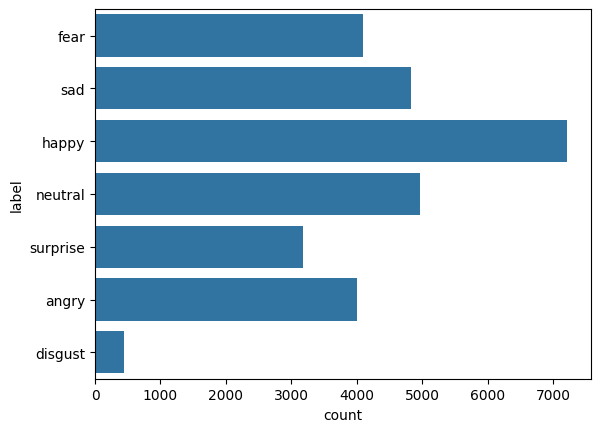

In [ ]:
###preprocessing

sns.countplot(train['label'])

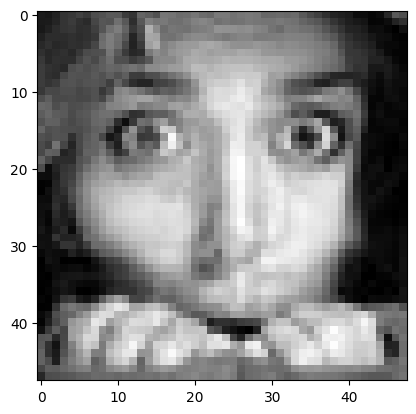

In [ ]:
img=Image.open(train['image'][0])
plt.imshow(img,cmap='gray')

In [ ]:
##Feature Extraction
def extract_features(images):
  features=[]
  for image in tqdm(images):
    img=load_img(image,color_mode='grayscale')
    img=np.array(img)
    features.append(img)
  features=np.array(features)
  features=features.reshape(len(features),48,48,1)
  return features
#

In [ ]:
train_features=extract_features(train['image'])
test_features=extract_features(test['image'])

100%|██████████| 7178/7178 [00:00<00:00, 7759.57it/s]


In [ ]:
#Normalize the image
X_train=train_features/255.0
X_test=test_features/255.0

In [ ]:
##convert label to integer
le=LabelEncoder()
y_train=le.fit_transform(train['label'])
y_test=le.fit_transform(test['label'])

In [ ]:
y_train=to_categorical(y_train,num_classes=7)
y_test=to_categorical(y_test,num_classes=7)

In [ ]:
##BUild the model
cnn = models.Sequential([
    # Block 1
    layers.Conv2D(128, (3,3), padding='same', activation='relu', input_shape=(48,48,1),kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.35),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),


    # Fully connected part
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])


In [ ]:
cnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#model summary
cnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 48, 48, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,385,927 (16.73 MB)

 Trainable params: 4,382,855 (16.72 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:
#training
history = cnn.fit(X_train, y_train, batch_size=128,epochs=100,validation_data=(X_test, y_test),callbacks=[early_stop])


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.2138 - loss: 2.1185 - val_accuracy: 0.2477 - val_loss: 1.8390
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.3004 - loss: 1.7159 - val_accuracy: 0.4111 - val_loss: 1.5506
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.3981 - loss: 1.5361 - val_accuracy: 0.4465 - val_loss: 1.4321
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.4516 - loss: 1.4167 - val_accuracy: 0.5021 - val_loss: 1.2766
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.4939 - loss: 1.3243 - val_accuracy: 0.5294 - val_loss: 1.2148
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.5210 - loss: 1.2489 - val_accuracy: 0.5495 - val_loss: 1.1655
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.5494 - loss: 1.2072 - val_accuracy: 0.5602 - val_loss: 1.1524
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.5592 - loss: 

In [ ]:
#model evaluation
test_loss, test_acc = cnn.evaluate(X_test,y_test,verbose=2)
print(test_acc)

225/225 - 2s - 10ms/step - accuracy: 0.6181 - loss: 1.0204
0.6181387305259705


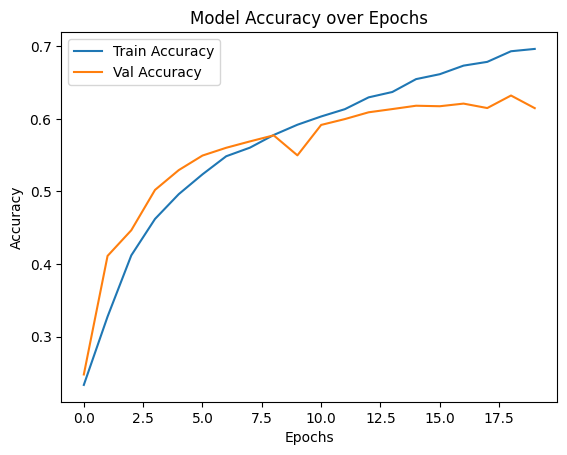

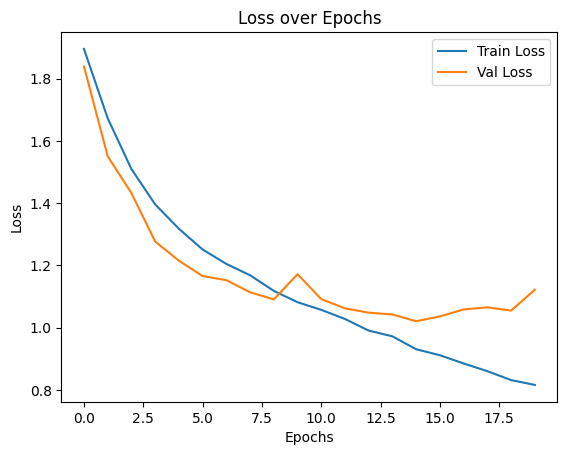

In [ ]:
#plot the tainnig data
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()


In [ ]:
# Model evaluation
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Compute predictions and F1 score
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# F1 Score (macro gives equal weight to each emotion)
f1 = f1_score(y_true, y_pred_classes, average='macro')
print(f"F1 Score (macro): {f1:.4f}")

# Optional: classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))


225/225 - 1s - 6ms/step - accuracy: 0.6181 - loss: 1.0204

Test Accuracy: 0.6181
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
F1 Score (macro): 0.5855

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.55      0.54       958
           1       0.64      0.46      0.53       111
           2       0.56      0.27      0.36      1024
           3       0.82      0.85      0.83      1774
           4       0.58      0.53      0.56      1233
           5       0.43      0.61      0.50      1247
           6       0.74      0.79      0.76       831

    accuracy                           0.62      7178
   macro avg       0.61      0.58      0.59      7178
weighted avg       0.62      0.62      0.61      7178



In [ ]:
##test with image data
random_images=random.randint(0,len(X_test)-1)
img=np.reshape(X_test[random_images],(1,48,48,1))
pred=cnn.predict(img)
print("Predicted class:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
Predicted class: 2


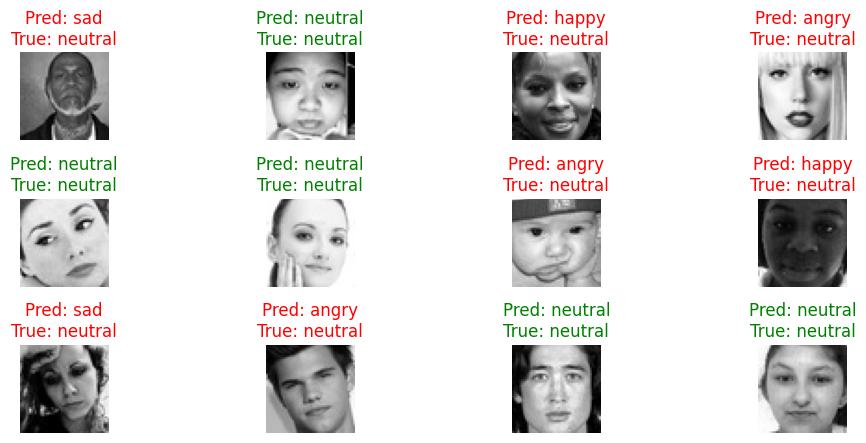

In [ ]:
#visualization
classes = le.classes_

# visualize
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[i].reshape(48,48), cmap='gray')

    pred = cnn.predict(X_test[i].reshape(1,48,48,1), verbose=0)
    pred_label = classes[np.argmax(pred)]
    true_label = classes[np.argmax(y_test[i])]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()




# **Task3**

In [ ]:
from zipfile import ZipFile
file_name = "/content/archive.zip"

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('done')

done


In [ ]:
#load the dataset
df = pd.read_csv('/content/data/train_solution_bounding_boxes (1).csv')
df['image_id'] = df['image'].apply(lambda x: x.split('.')[0])
df['classes'] = 0   # Single class = car

df.head()


,image,xmin,ymin,xmax,ymax,image_id,classes
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,vid_4_1000,0
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,vid_4_10000,0
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180,vid_4_10040,0
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575,vid_4_10020,0
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422,vid_4_10060,0


In [ ]:
##Image and label configuration
#Inintailize configuration
img_h, img_w = 380, 676
images_folder = '/content/data/training_images'

In [ ]:
# Convert bounding box to YOLO format
df['x_center'] = (df['xmin'] + df['xmax']) / 2
df['y_center'] = (df['ymin'] + df['ymax']) / 2
df['w'] = df['xmax'] - df['xmin']
df['h'] = df['ymax'] - df['ymin']

In [ ]:
# Normalize values
df['x_center'] /= img_w
df['y_center'] /= img_h
df['w'] /= img_w
df['h'] /= img_h

In [ ]:
print(df[['x_center', 'y_center', 'w', 'h']].head())

   x_center  y_center         w         h
0  0.450434  0.539817  0.068741  0.095238
1  0.100217  0.557191  0.155572  0.129987
2  0.444645  0.543678  0.181621  0.157014
3  0.833213  0.531451  0.197540  0.155727
4  0.110347  0.559122  0.171491  0.136422


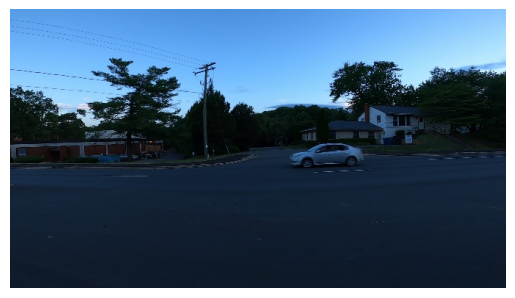

In [ ]:
##EDA
image=random.choice(df['image'])
image_path=os.path.join(images_folder,image)
img=Image.open(image_path)
plt.axis("off")
plt.imshow(img)

In [ ]:
##Visualize random image with BOunding BOx

def draw_bounding_box(idx):
    image_path = os.path.join(images_folder, df.loc[idx, 'image'])
    image = cv2.imread(image_path)
    x_min, x_max = int(df.loc[idx, 'xmin']), int(df.loc[idx, 'xmax'])
    y_min, y_max = int(df.loc[idx, 'ymin']), int(df.loc[idx, 'ymax'])
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0,255,0), 2)
    cv2.putText(image, 'car', (x_min, y_min-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

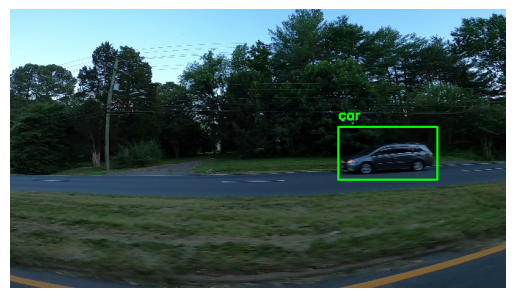

In [ ]:
random_idx=random.randrange(0,len(df)-1)
draw_bounding_box(random_idx)

In [ ]:
#Create YOLOv8 Annotation Files
annotation_folder='/content/data/annotation/'
if not os.path.exists(annotation_folder):
  os.makedirs(annotation_folder)

In [ ]:
for image_file, group in df.groupby('image'):
    txt_path = os.path.join(annotation_folder, os.path.splitext(image_file)[0] + '.txt')
    with open(txt_path, 'w') as f:
        for _, row in group.iterrows():
            f.write(f"{row['classes']} {row['x_center']} {row['y_center']} {row['w']} {row['h']}\n")

print(" YOLO annotations created successfully")


 YOLO annotations created successfully


In [ ]:
##Split Dataset (Train/Test)
images = df['image'].unique()
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

In [ ]:
# Directory setup
dataset_dir = '/content/data/dataset'
train_images_dir = os.path.join(dataset_dir, 'train', 'images')
train_labels_dir = os.path.join(dataset_dir, 'train', 'labels')
val_images_dir = os.path.join(dataset_dir, 'val', 'images')
val_labels_dir = os.path.join(dataset_dir, 'val', 'labels')

for path in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
    os.makedirs(path, exist_ok=True)

In [ ]:
# Copy files
def copy_files(image_list, dest_img_folder, dest_label_folder):
    for image_file in image_list:
        img_src = os.path.join(images_folder, image_file)
        label_src = os.path.join(annotation_folder, os.path.splitext(image_file)[0] + '.txt')
        if os.path.exists(img_src) and os.path.exists(label_src):
            sh.copy(img_src, dest_img_folder)
            sh.copy(label_src, dest_label_folder)


In [ ]:
copy_files(train_imgs, train_images_dir, train_labels_dir)
copy_files(test_imgs, val_images_dir, val_labels_dir)

In [ ]:
##Model Training
##Create data.yaml for YOLOv8
yaml_content = f"""
train: {dataset_dir}/train
val: {dataset_dir}/val

nc: 1
names: ['car']
"""

with open('/content/data/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created")

data.yaml created


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.0 MB/s eta 0:00:00


In [ ]:
#Load and Train YOLOv8 Model
import ultralytics
from ultralytics import YOLO
model = YOLO('yolov8n.pt')  # Pre-trained small model (YOLOv8n)
model.train(data='/content/data/data.yaml',
            epochs=50,
            batch=16,
            imgsz=640,
            workers=2)

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb99ff4c980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
##Evaluate Model
metrics = model.val()
print("Validation metrics (includes mAP):", metrics)



Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2273.7±784.4 MB/s, size: 102.9 KB)
val: Scanning /content/data/dataset/val/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 89.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.2it/s 1.6s
                   all         71        119      0.999       0.95       0.98      0.679
Speed: 5.3ms preprocess, 5.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
Validation metrics (includes mAP): ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eba5ae4e060>
curves: ['Precision-Recall


image 1/1 /content/data/dataset/val/images/vid_4_9760.jpg: 384x640 3 cars, 39.7ms
Speed: 1.5ms preprocess, 39.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


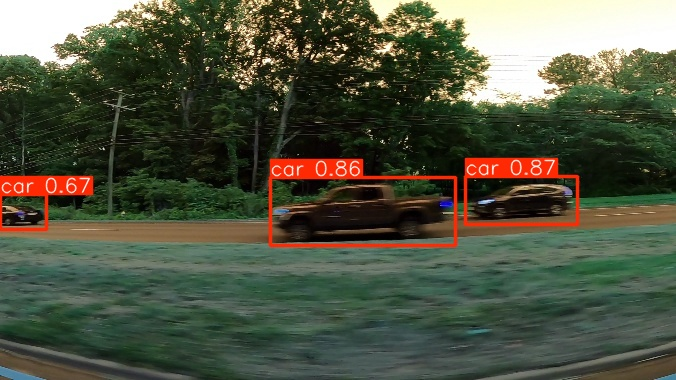


image 1/1 /content/data/dataset/val/images/vid_4_30440.jpg: 384x640 1 car, 9.2ms
Speed: 2.4ms preprocess, 9.2ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


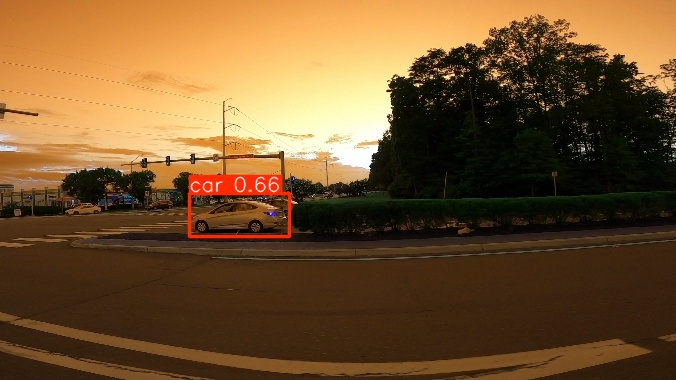


image 1/1 /content/data/dataset/val/images/vid_4_9660.jpg: 384x640 1 car, 8.5ms
Speed: 2.5ms preprocess, 8.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


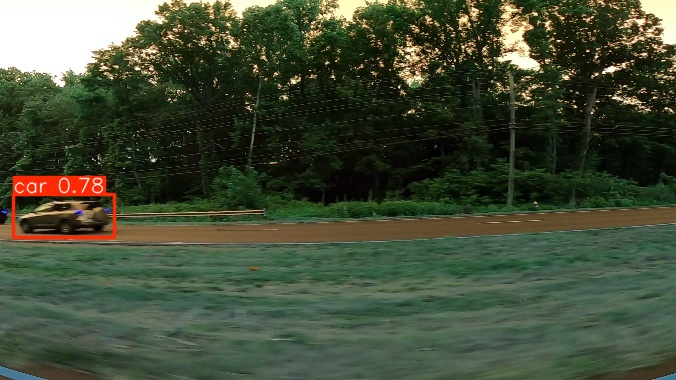

In [ ]:
#Visualize Detected Objects
best_model = YOLO('/content/runs/detect/train/weights/best.pt')

sample_images = random.sample(list(test_imgs), 3)

for img_name in sample_images:
    img_path = os.path.join(val_images_dir, img_name)
    results = best_model.predict(source=img_path, conf=0.25)
    for r in results:
        im_array = r.plot()  # draw bounding boxes and confidence
        output_path = f"/content/pred_{img_name}"
        cv2.imwrite(output_path, im_array[:, :, ::-1])
        display(IPImage(filename=output_path))


In [ ]:
##View Training Loss Components
results_csv = '/content/runs/detect/train/results.csv'
df_results = pd.read_csv(results_csv)

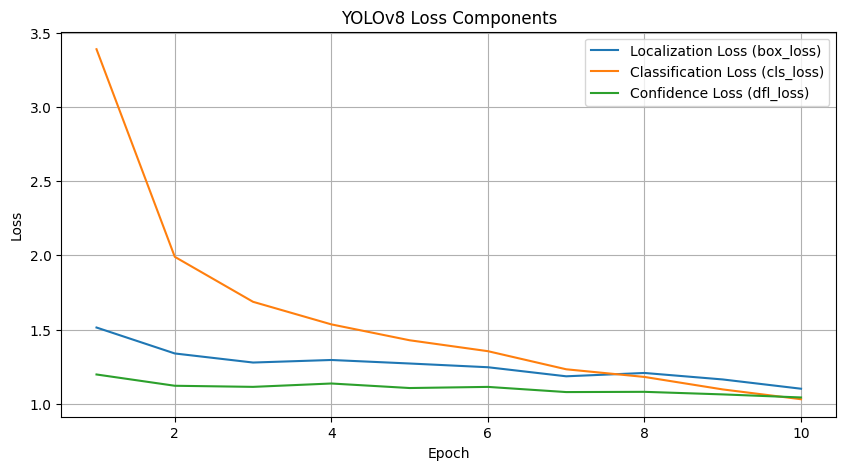

In [ ]:
# Plot localization (box) loss and confidence loss
plt.figure(figsize=(10,5))
plt.plot(df_results['epoch'], df_results['train/box_loss'], label='Localization Loss (box_loss)')
plt.plot(df_results['epoch'], df_results['train/cls_loss'], label='Classification Loss (cls_loss)')
plt.plot(df_results['epoch'], df_results['train/dfl_loss'], label='Confidence Loss (dfl_loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLOv8 Loss Components')
plt.legend()
plt.grid(True)
plt.show()

# **TASK4**

In [ ]:
from zipfile import ZipFile

file_name = "/content/archive (1).zip"

with ZipFile(file_name, 'r') as zip_file:  # NOT 'zip'
    zip_file.extractall("/content")
    print("ZIP extraction done!")


ZIP extraction done!


In [ ]:
image_paths = sorted(glob("/content/images/*"))
mask_paths = sorted(glob("/content/masks/*"))
print("Found", len(image_paths), "images")
print("Found", len(mask_paths), "masks")


Found 3064 images
Found 3064 masks


In [ ]:
IMG_HEIGHT, IMG_WIDTH = 128, 128

In [ ]:
def load_image(image_path, mask_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)  # shape (128,128,1)

    return img, mask

In [ ]:
images, masks = zip(*[load_image(i, m) for i, m in zip(image_paths, mask_paths)])
images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (3064, 128, 128, 3)
Masks shape: (3064, 128, 128, 1)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("Training set:", x_train.shape, y_train.shape)
print("Testing set:", x_test.shape, y_test.shape)

Training set: (2451, 128, 128, 3) (2451, 128, 128, 1)
Testing set: (613, 128, 128, 3) (613, 128, 128, 1)


In [ ]:
##Define Dice and IoU metrics
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return bce + dl


In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    return x

In [ ]:
def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = layers.MaxPooling2D((2,2))(f)
    return f, p

In [ ]:
def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.concatenate([x, skip])
    x = conv_block(x, filters)
    return x

In [ ]:
from tensorflow.keras import layers, Model

def build_unet(input_shape=(128,128,3)):
    inputs = layers.Input(shape=input_shape)

    f1, p1 = encoder_block(inputs, 64)
    f2, p2 = encoder_block(p1, 128)
    f3, p3 = encoder_block(p2, 256)
    f4, p4 = encoder_block(p3, 512)

    bottleneck = conv_block(p4, 1024)

    d1 = decoder_block(bottleneck, f4, 512)
    d2 = decoder_block(d1, f3, 256)
    d3 = decoder_block(d2, f2, 128)
    d4 = decoder_block(d3, f1, 64)

    outputs = layers.Conv2D(1, (1,1), activation="sigmoid")(d4)
    model = Model(inputs, outputs, name="U-Net")
    return model


In [ ]:
model = build_unet()
model.compile(optimizer="adam", loss=bce_dice_loss,
              metrics=["accuracy", dice_coefficient, iou_metric])
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

#  Train Model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True, monitor='val_loss', mode='min')

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 42s 271ms/step - accuracy: 0.9824 - dice_coefficient: 0.4221 - iou_metric: 0.2721 - loss: 0.6517 - val_accuracy: 0.9842 - val_dice_coefficient: 0.5090 - val_iou_metric: 0.3447 - val_loss: 0.5704
Epoch 2/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 60s 388ms/step - accuracy: 0.9833 - dice_coefficient: 0.4764 - iou_metric: 0.3199 - loss: 0.5995 - val_accuracy: 0.9862 - val_dice_coefficient: 0.5596 - val_iou_metric: 0.3913 - val_loss: 0.4947
Epoch 3/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 37s 241ms/step - accuracy: 0.9854 - dice_coefficient: 0.5413 - iou_metric: 0.3786 - loss: 0.5255 - val_accuracy: 0.9823 - val_dice_coefficient: 0.0294 - val_iou_metric: 0.0150 - val_loss: 1.0460
Epoch 4/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 235ms/step - accuracy: 0.9808 - dice_coefficient: 0.0813 - iou_metric: 0.0429 - loss: 1.0036 - val_accuracy: 0.9814 - val_dice_coefficient: 0.0932 - val_iou_metric: 0.0494 - val_loss: 0.9891
Epoch 5/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - acc

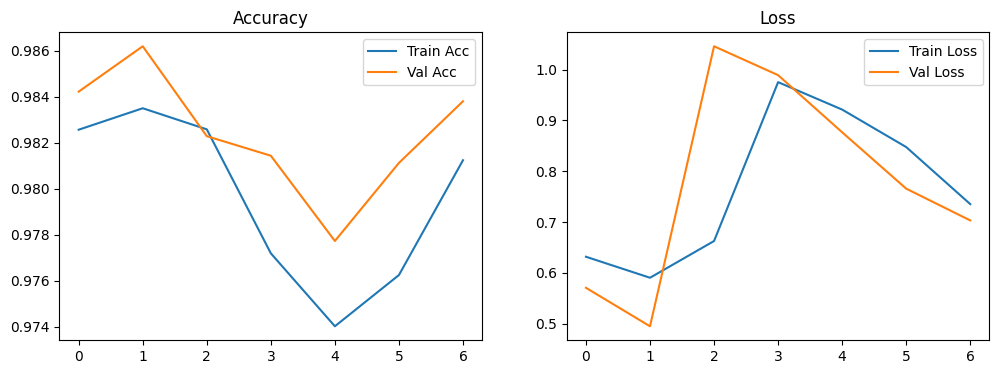

In [ ]:

# Plot accuracy and loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

In [ ]:
# Visualize segmentation predictions

def display_sample(img, true_mask, pred_mask):
    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Input Image"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(true_mask.squeeze(), cmap='gray'); plt.title("True Mask"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(pred_mask.squeeze(), cmap='gray'); plt.title("Predicted Mask"); plt.axis('off')
    plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step


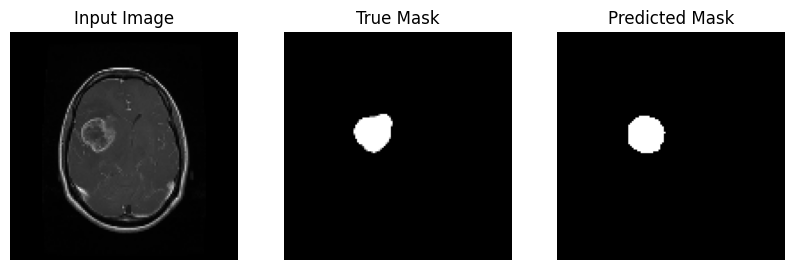

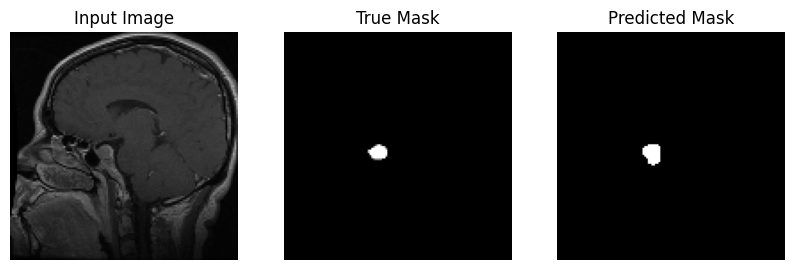

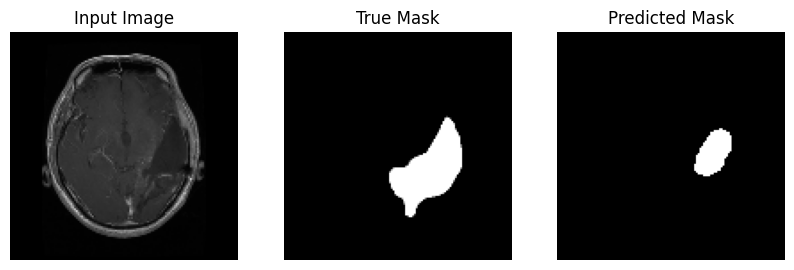

In [ ]:
# Predict and display results
preds = model.predict(x_test)
preds = (preds > 0.5).astype(np.float32)

for i in range(3):
    display_sample(x_test[i], y_test[i], preds[i])

# **TASK 5**

In [ ]:
def load_img(path_to_img, max_dim=512):
    img = Image.open(path_to_img)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    long = max(img.size)
    scale = max_dim / long
    new_size = (round(img.size[0] * scale), round(img.size[1] * scale))
    img = img.resize(new_size, Image.LANCZOS)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return img

In [ ]:
def imshow(image, title=None):
    if len(image.shape) == 4:
        image = np.squeeze(image, 0)
    image = np.clip(image, 0, 255).astype('uint8')
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

In [ ]:
def preprocess_vgg(img):
    if isinstance(img, np.ndarray):
        x = img.copy()
    else:
        x = tf.identity(img)
    return tf.keras.applications.vgg19.preprocess_input(x)


In [ ]:
def deprocess_img(processed_img):
    x = processed_img.copy()
    if len(x.shape) == 4:
        x = np.squeeze(x, 0)
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    return np.clip(x, 0, 255).astype('uint8')

In [ ]:
def gram_matrix(x):
    x = tf.transpose(x, (0, 3, 1, 2))
    b, c, h, w = x.shape
    features = tf.reshape(x, (b, c, h * w))
    gram = tf.matmul(features, features, transpose_b=True)
    return gram / tf.cast(c * h * w, tf.float32)


In [ ]:
# VGG model setup
CONTENT_LAYERS = ['block5_conv2']
STYLE_LAYERS = [
    'block1_conv1', 'block2_conv1',
    'block3_conv1', 'block4_conv1', 'block5_conv1'
]


In [ ]:
def get_model():
    vgg = vgg19.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in STYLE_LAYERS + CONTENT_LAYERS]
    return models.Model([vgg.input], outputs)


In [ ]:
##Loss FUnction
def get_feature_representations(model, content_image, style_image):
    content_image = preprocess_vgg(content_image)
    style_image = preprocess_vgg(style_image)

    style_outputs = model(style_image)
    content_outputs = model(content_image)

    style_features = [layer for layer in style_outputs[:len(STYLE_LAYERS)]]
    content_features = [layer for layer in content_outputs[len(STYLE_LAYERS):]]
    return style_features, content_features

In [ ]:
def compute_loss(model, loss_weights, init_image, gram_style_features, content_features):
    style_weight, content_weight, tv_weight = loss_weights
    model_outputs = model(preprocess_vgg(init_image))

    style_output_features = model_outputs[:len(STYLE_LAYERS)]
    content_output_features = model_outputs[len(STYLE_LAYERS):]


    style_score = 0.0
    weight_per_style_layer = 1.0 / float(len(STYLE_LAYERS))
    for target_style, comb_style in zip(gram_style_features, style_output_features):
        gram_comb_style = gram_matrix(comb_style)
        style_score += weight_per_style_layer * tf.reduce_mean(tf.square(gram_comb_style - target_style))


    content_score = 0.0
    for target_content, comb_content in zip(content_features, content_output_features):
        content_score += tf.reduce_mean(tf.square(comb_content - target_content))

    tv_score = tf.reduce_sum(tf.image.total_variation(init_image))

    style_score *= style_weight
    content_score *= content_weight
    tv_score *= tv_weight

    loss = style_score + content_score + tv_score
    return loss, style_score, content_score, tv_score

In [ ]:
##Style Transfer Function
def run_style_transfer(content_path, style_path,
                       num_iterations=300,
                       content_weight=1e3,
                       style_weight=1e-2,
                       tv_weight=30.0):

    print("Starting Neural Style Transfer...")
    content_image = load_img(content_path)
    style_image = load_img(style_path)

    model = get_model()
    for layer in model.layers:
        layer.trainable = False

    style_features, content_features = get_feature_representations(model, content_image, style_image)
    gram_style_features = [gram_matrix(style_feature) for style_feature in style_features]

    init_image = tf.Variable(content_image, dtype=tf.float32)
    opt = tf.optimizers.Adam(learning_rate=5.0)
    loss_weights = (style_weight, content_weight, tv_weight)

    best_loss, best_img = float('inf'), None
    loss_history = []

    @tf.function()
    def train_step():
        with tf.GradientTape() as tape:
            loss, style_score, content_score, tv_score = compute_loss(
                model, loss_weights, init_image, gram_style_features, content_features)
        grad = tape.gradient(loss, init_image)
        opt.apply_gradients([(grad, init_image)])
        init_image.assign(tf.clip_by_value(init_image, 0.0, 255.0))
        return loss, style_score, content_score, tv_score

    for i in range(num_iterations):
        loss, s_loss, c_loss, t_loss = train_step()
        loss_history.append((loss.numpy(), s_loss.numpy(), c_loss.numpy(), t_loss.numpy()))
        if loss.numpy() < best_loss:
            best_loss = loss.numpy()
            best_img = deprocess_img(init_image.numpy())
        if i % 50 == 0:
            print(f"Step {i}, Total Loss: {loss.numpy():.4e}, Style: {s_loss.numpy():.4e}, Content: {c_loss.numpy():.4e}")

    print(" Style Transfer Complete!")
    return best_img, loss_history


In [ ]:
content_path = '/content/profile.jfif'
style_path   = '/content/monet.jpeg'
best_img, history = run_style_transfer(content_path, style_path, num_iterations=100)

Starting Neural Style Transfer...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_98']
Received: inputs=Tensor(shape=(1, 496, 512, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_98']
Received: inputs=Tensor(shape=(1, 512, 512, 3))
  warnings.warn(msg)


Step 0, Total Loss: 6.0978e+07, Style: 1.7727e+03, Content: 3.2423e-07
Step 50, Total Loss: 4.7620e+07, Style: 2.0036e+03, Content: 5.4369e+05
 Style Transfer Complete!


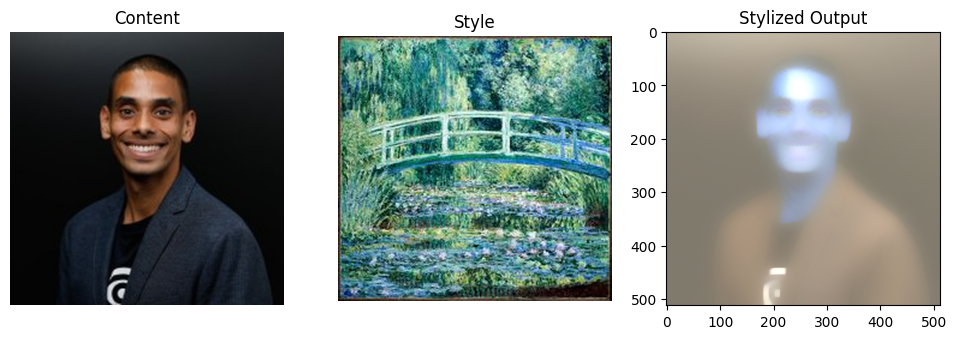

In [ ]:
#ivusalize
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); imshow(load_img(content_path)); plt.title('Content')
plt.subplot(1,3,2); imshow(load_img(style_path)); plt.title('Style')
plt.subplot(1,3,3); plt.imshow(best_img); plt.title('Stylized Output')
plt.show()